# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import mean_squared_error, structural_similarity

In [2]:
median_params = [3, 5, 7, 9]
gauss_params = [(3,3), (5,5), (7,7), (9,9)]
bilateral_params = [(5,50,50), (9,75,75), (9,150,150), (15,150,150)]
nlm_params = [5, 10, 20, 30]

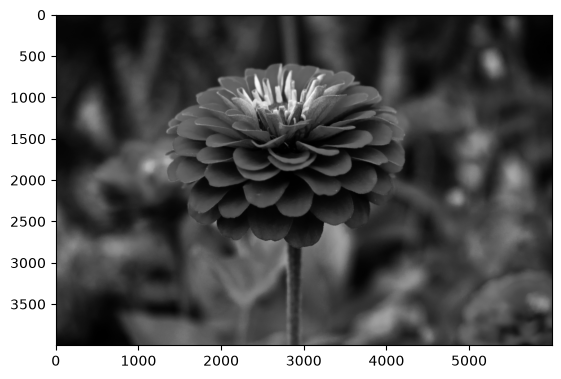

In [3]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
plt.imshow(image_gray, cmap="gray")

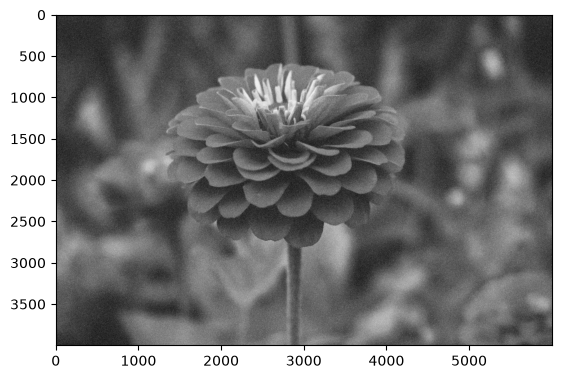

In [4]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

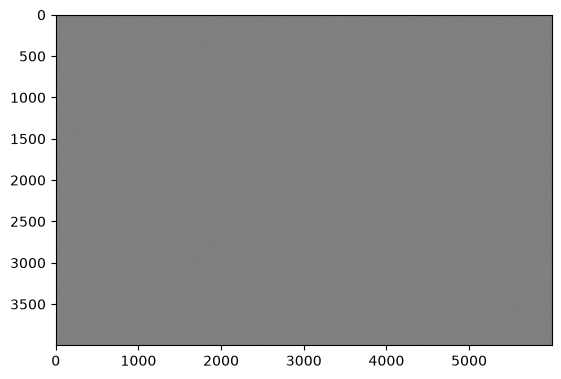

In [ ]:
# 0 represents black (pepper)
# 100 represents white (salt)
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)
image_sp = np.ones(image_gray.shape, np.uint8) * 128
image_sp = image_gray.copy()
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255
plt.imshow(image_sp, cmap="gray")

gauss noise, k=3: MSE=844.0684, SSIM=0.1536


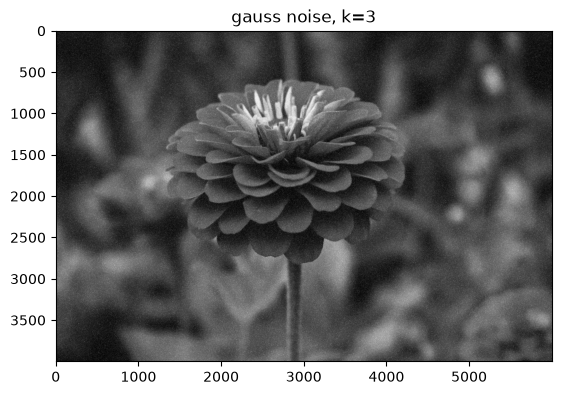

gauss noise, k=5: MSE=333.2518, SSIM=0.3658


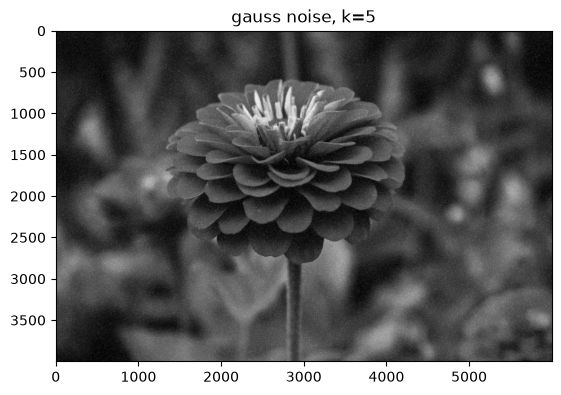

gauss noise, k=7: MSE=188.6647, SSIM=0.5445


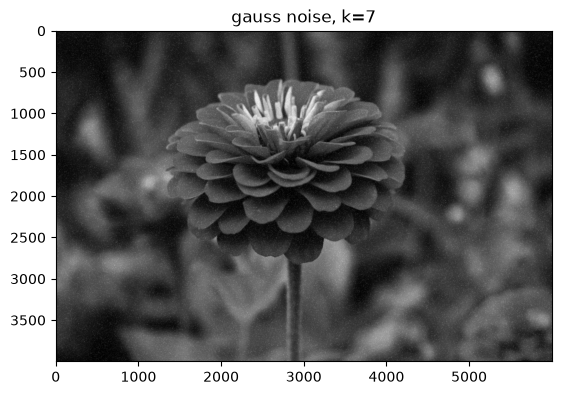

gauss noise, k=9: MSE=131.4838, SSIM=0.6549


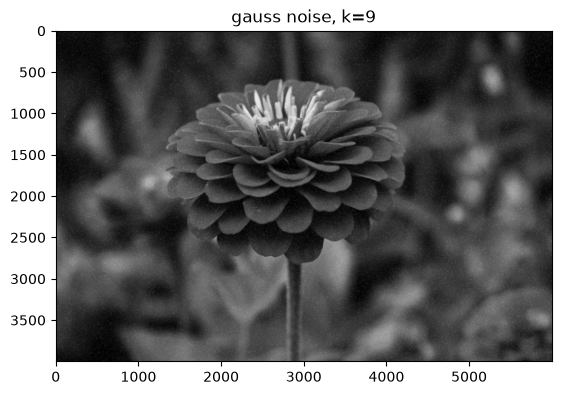

salt&pepper, k=3: MSE=6358.1730, SSIM=0.5162


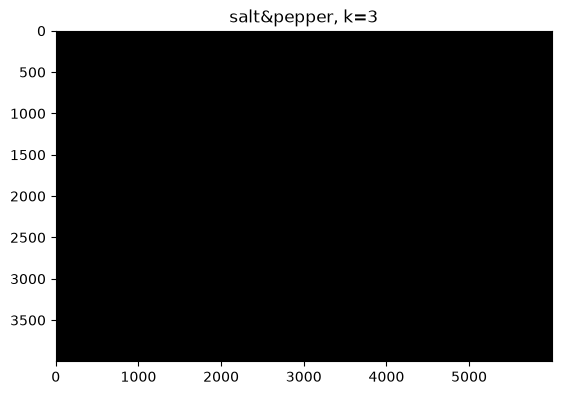

salt&pepper, k=5: MSE=6358.1730, SSIM=0.5162


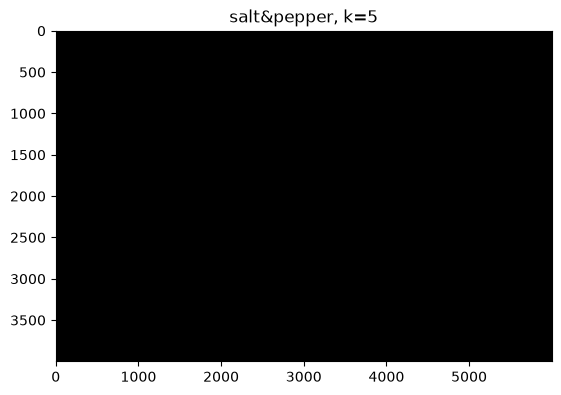

salt&pepper, k=7: MSE=6358.1730, SSIM=0.5162


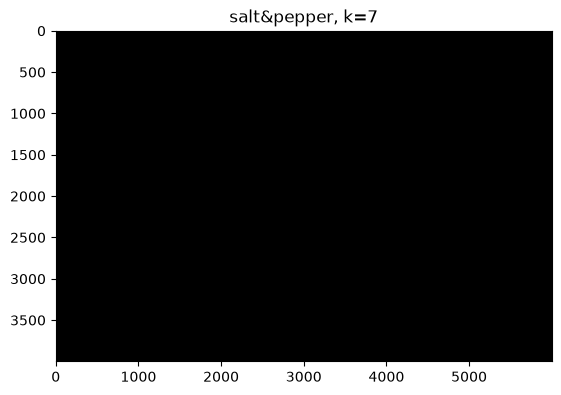

salt&pepper, k=9: MSE=6358.1730, SSIM=0.5162


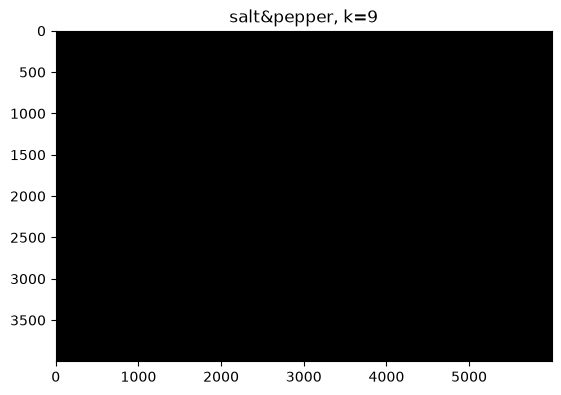

In [6]:
#median filtering

for k in median_params:
    res = cv2.medianBlur(image_noise_gauss, k)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, k={k}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'gauss noise, k={k}')
    plt.show()

for k in median_params:
    res = cv2.medianBlur(image_sp, k)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'salt&pepper, k={k}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'salt&pepper, k={k}')
    plt.show()


gauss noise, ksize=(3, 3): MSE=1926.5136, SSIM=0.1412


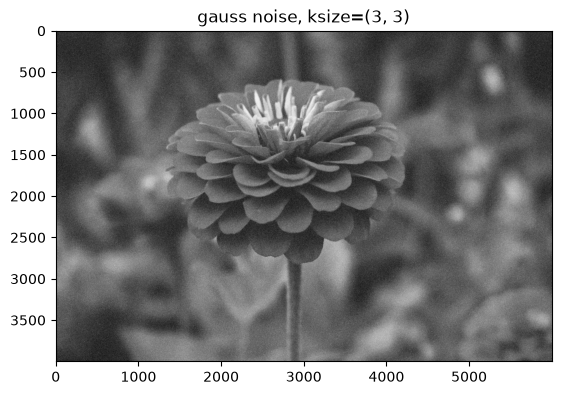

gauss noise, ksize=(5, 5): MSE=1729.2054, SSIM=0.2304


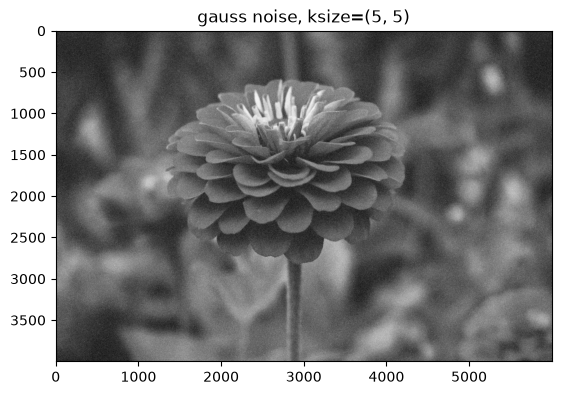

gauss noise, ksize=(7, 7): MSE=1627.5582, SSIM=0.3475


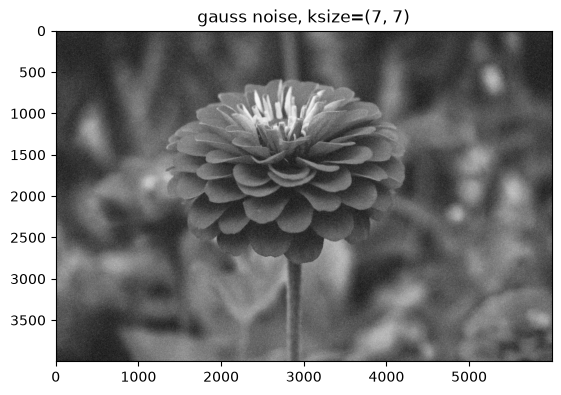

gauss noise, ksize=(9, 9): MSE=1591.5993, SSIM=0.4210


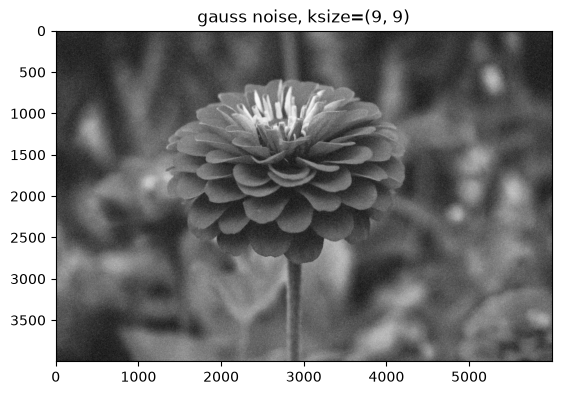

salt&pepper, ksize=(3, 3): MSE=6403.2419, SSIM=0.3640


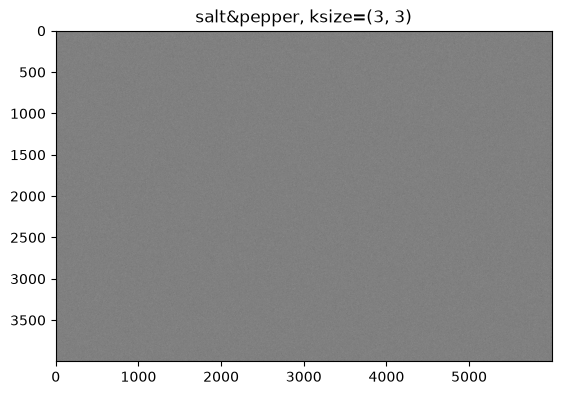

salt&pepper, ksize=(5, 5): MSE=6380.8213, SSIM=0.4186


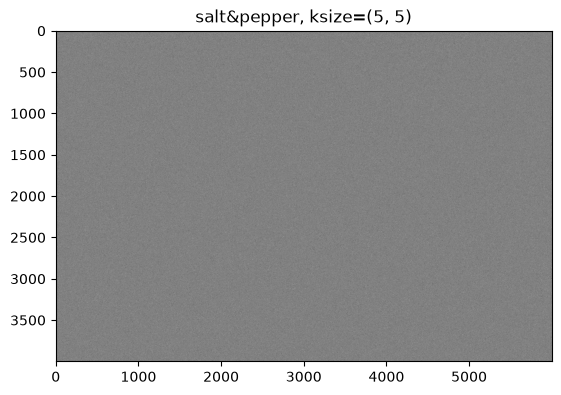

salt&pepper, ksize=(7, 7): MSE=6370.2002, SSIM=0.4617


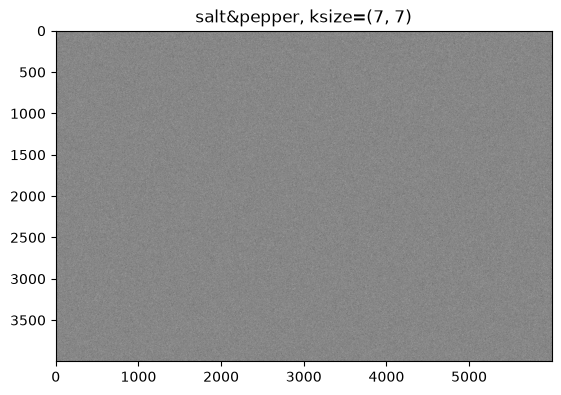

salt&pepper, ksize=(9, 9): MSE=6364.2716, SSIM=0.4801


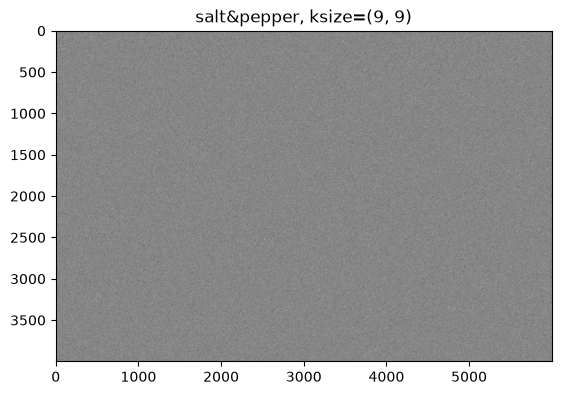

In [7]:
for ksize in gauss_params:
    res = cv2.GaussianBlur(image_noise_gauss, ksize, 0)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, ksize={ksize}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'gauss noise, ksize={ksize}')
    plt.show()
for ksize in gauss_params:
    res = cv2.GaussianBlur(image_sp, ksize, 0)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'salt&pepper, ksize={ksize}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')

    plt.imshow(res, cmap='gray')
    plt.title(f'salt&pepper, ksize={ksize}')
    plt.show()
    

gauss noise, d=5, sc=50, ss=50: MSE=3048.2273, SSIM=0.0427


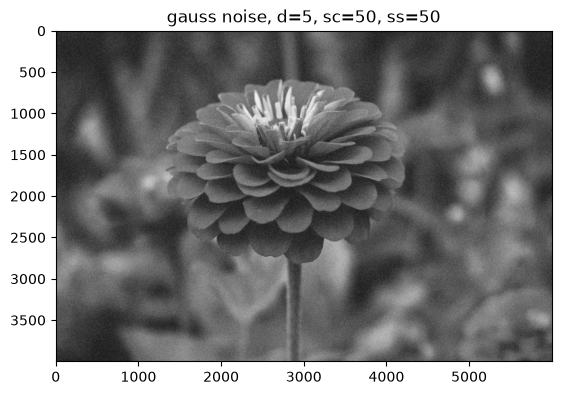

gauss noise, d=9, sc=75, ss=75: MSE=1786.3904, SSIM=0.1045


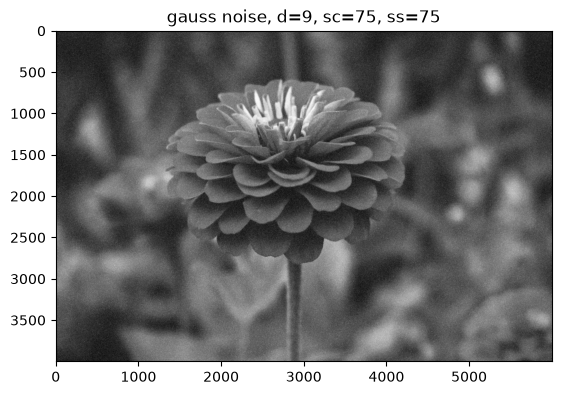

gauss noise, d=9, sc=150, ss=150: MSE=1362.9824, SSIM=0.3525


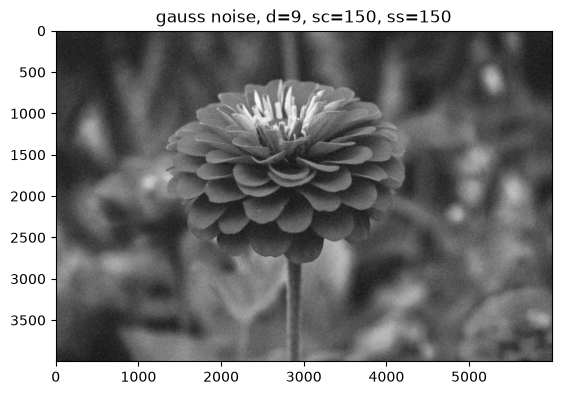

gauss noise, d=15, sc=150, ss=150: MSE=1310.0955, SSIM=0.4154


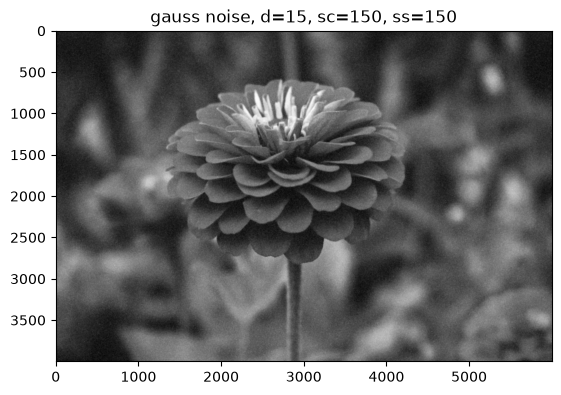

salt&pepper, d=5, sc=50, ss=50: MSE=6499.3474, SSIM=0.2756


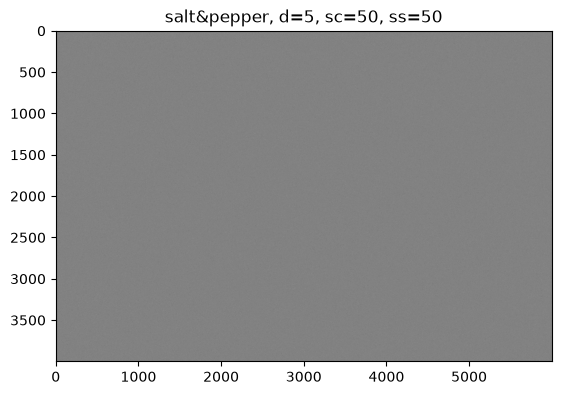

salt&pepper, d=9, sc=75, ss=75: MSE=6362.3826, SSIM=0.4865


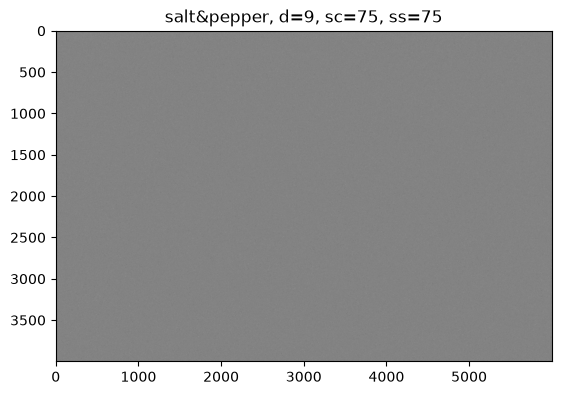

salt&pepper, d=9, sc=150, ss=150: MSE=6362.1034, SSIM=0.4991


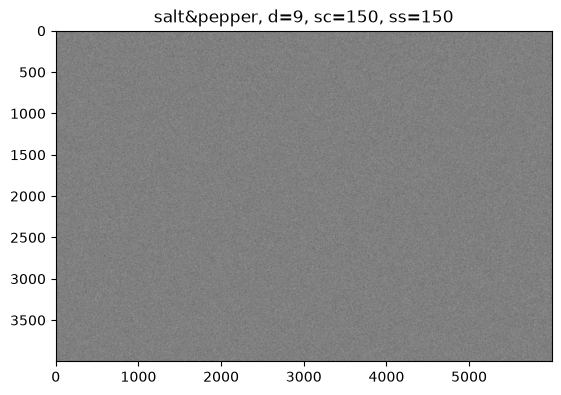

salt&pepper, d=15, sc=150, ss=150: MSE=6359.2018, SSIM=0.5122


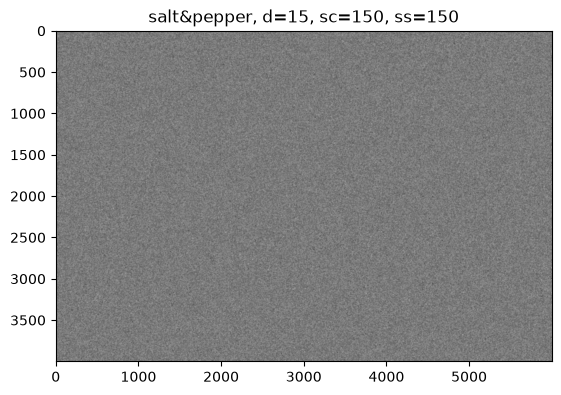

In [8]:
for d, sigma_color, sigma_space in bilateral_params:
    res = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, d={d}, sc={sigma_color}, ss={sigma_space}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'gauss noise, d={d}, sc={sigma_color}, ss={sigma_space}')
    plt.show()

for d, sigma_color, sigma_space in bilateral_params:
    res = cv2.bilateralFilter(image_sp, d, sigma_color, sigma_space)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'salt&pepper, d={d}, sc={sigma_color}, ss={sigma_space}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'salt&pepper, d={d}, sc={sigma_color}, ss={sigma_space}')
    plt.show()
    

gauss noise, h=5: MSE=4498.4956, SSIM=0.0259


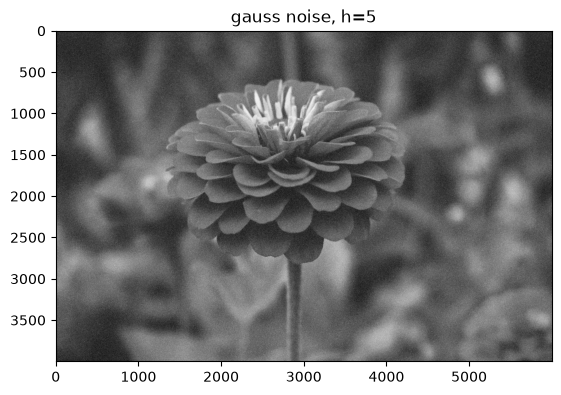

gauss noise, h=10: MSE=4498.3586, SSIM=0.0261


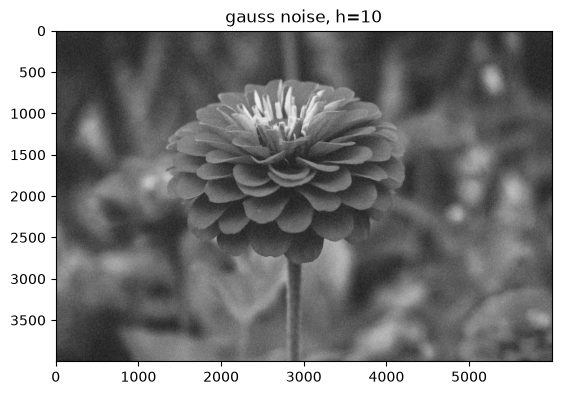

gauss noise, h=20: MSE=4486.2696, SSIM=0.0289


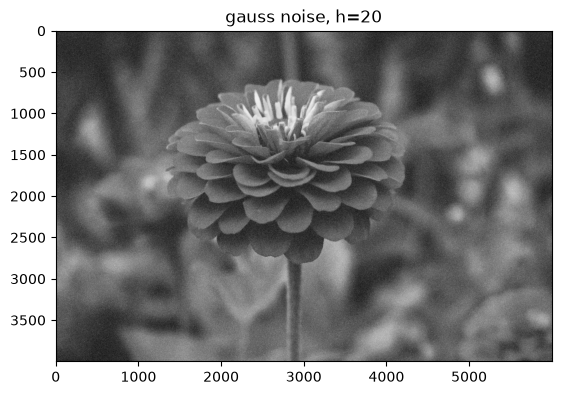

gauss noise, h=30: MSE=2778.2937, SSIM=0.0833


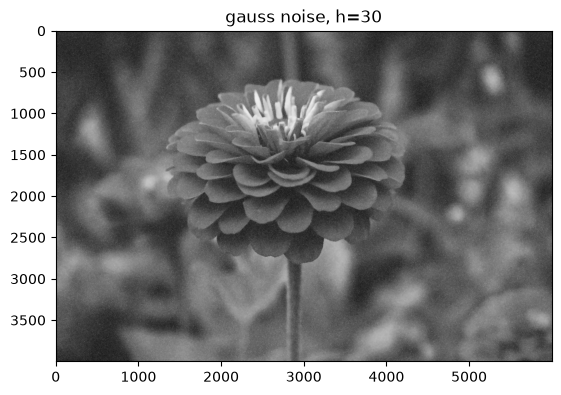

salt&pepper, h=5: MSE=6677.5231, SSIM=0.2401


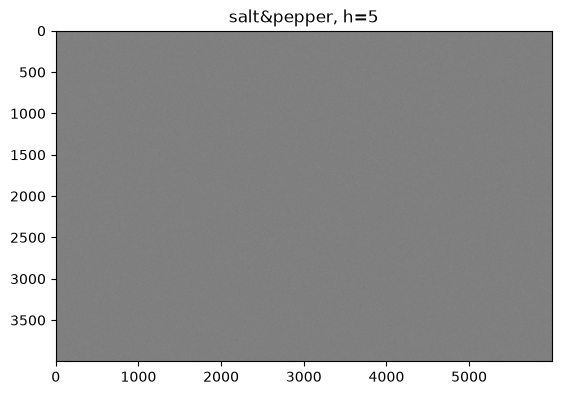

salt&pepper, h=10: MSE=6526.8429, SSIM=0.3228


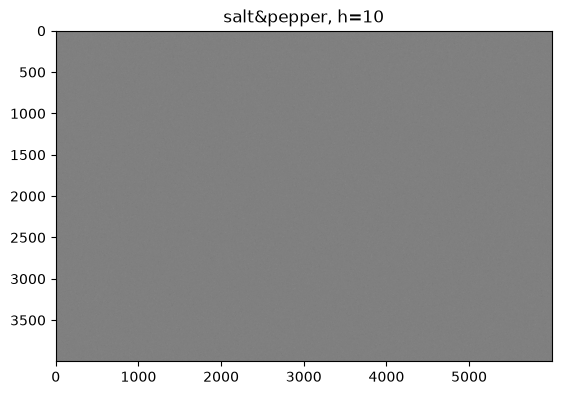

salt&pepper, h=20: MSE=6359.8132, SSIM=0.5075


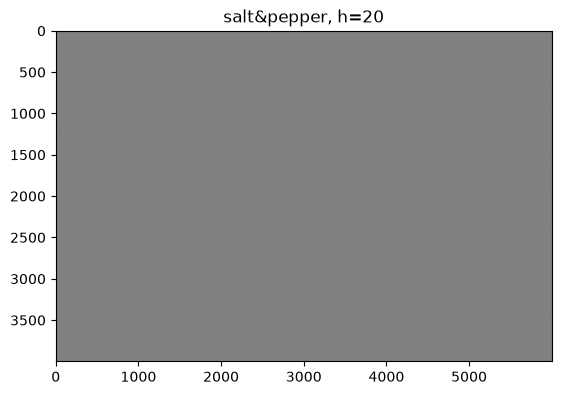

salt&pepper, h=30: MSE=6358.0669, SSIM=0.5142


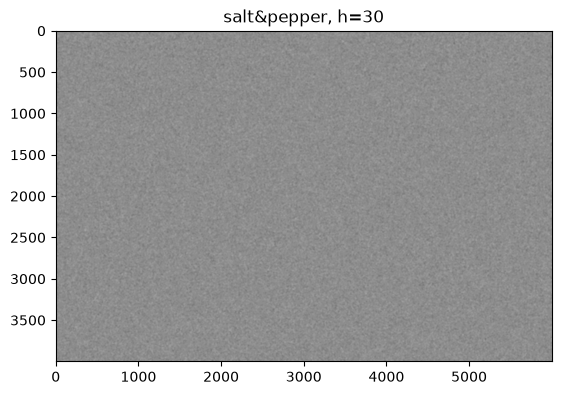

In [9]:
for h in nlm_params:
    res = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'gauss noise, h={h}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray');
    plt.title(f'gauss noise, h={h}')
    plt.show()

for h in nlm_params:
    res = cv2.fastNlMeansDenoising(image_sp, h=h)
    mse_val = mean_squared_error(image_gray, res)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    print(f'salt&pepper, h={h}: MSE={mse_val:.4f}, SSIM={ssim_val:.4f}')
    plt.imshow(res, cmap='gray')
    plt.title(f'salt&pepper, h={h}')
    plt.show()

In [10]:
#comparing using SSIM

results_gauss_noise = {}
results_sp_noise = {}

for k in median_params:
    res = cv2.medianBlur(image_noise_gauss, k)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'median k={k}'] = ssim_val

    res = cv2.medianBlur(image_sp, k)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_sp_noise[f'median k={k}'] = ssim_val

for ksize in gauss_params:
    res = cv2.GaussianBlur(image_noise_gauss, ksize, 0)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'gaussian ksize={ksize}'] = ssim_val

    res = cv2.GaussianBlur(image_sp, ksize, 0)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_sp_noise[f'gaussian ksize={ksize}'] = ssim_val

for d, sigma_color, sigma_space in bilateral_params:
    res = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'bilateral d={d},sc={sigma_color},ss={sigma_space}'] = ssim_val

    res = cv2.bilateralFilter(image_sp, d, sigma_color, sigma_space)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_sp_noise[f'bilateral d={d},sc={sigma_color},ss={sigma_space}'] = ssim_val

for h in nlm_params:
    res = cv2.fastNlMeansDenoising(image_noise_gauss, h=h)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_gauss_noise[f'nlm h={h}'] = ssim_val

    res = cv2.fastNlMeansDenoising(image_sp, h=h)
    (ssim_val, diff) = structural_similarity(image_gray, res, full=True)
    results_sp_noise[f'nlm h={h}'] = ssim_val

best_gauss = max(results_gauss_noise, key=results_gauss_noise.get)
best_sp = max(results_sp_noise, key=results_sp_noise.get)

print(f'gauss noise best: {best_gauss}, SSIM={results_gauss_noise[best_gauss]:.4f}')
print(f'salt&pepper best: {best_sp}, SSIM={results_sp_noise[best_sp]:.4f}')

gauss noise best: median k=9, SSIM=0.6549
salt&pepper best: median k=3, SSIM=0.5162
